# Spectral analysis of MBARI data from Elkhorn Slough 

To demonstrate how the Fourier transform can be calculated numerically to create a power spectrum, we use data from the Land Ocean Biogeochemical Observatory in Elkhorn Slough. The data come from the L01 buoy just up channel from the Highway 1 bridge. This buoy is maintained by Dr. Ken Johnson's Chemical Sensors group at MBARI, which develops new technology in order to understand high-frequency fluctuations in biogeochemical parameters over long time periods.

![LOBO Map](https://www3.mbari.org/lobo/pictures/maps/network2.jpg)

The data can be downloaded in text format at this site:
http://www3.mbari.org/lobo/getLOBOdata.htm

## Loading the data

This first "magic" command is optional. It creates interactive figures. It requires installation of the [ipympl](https://github.com/matplotlib/ipympl) package (inlcuded in the course notes for software installation).

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt

filename = 'data/MBARI_LOBO/L01SURF_subset.txt'
data = np.genfromtxt(filename,delimiter=',',skip_header=3)

After loading the data, missing values are replaced with NaNs and three variables are created from the larger data set: time (days since 1/1/1900), nitrate ($\mu$M) and water depth (m). These data are a small continuous subset of the multi-year time series from 1 January - 22 March 2007.

In [3]:
flagi = np.where(data>1E100)
data[flagi] = np.nan

time = data[:,1]
nitrate = data[:,2]
waterdep = data[:,3]
salinity = data[:,4]
temp = data[:,5]

## Plotting the data

First, it is always helpful to plot the data in the time domain to get a visual sense of the variability. The data set is about 80 days long. The water depth plot primarily shows the tides, which have a fortnightly spring-neap cycle. The nitrate data also show high-frequency variability due to the tides, but there are also irregular pulses of high nitate. This is the winter season, and freshwater runoff from storms can have very high nitrate concentrations because of of all the agriculture in the watershed.

Text(0, 0.5, 'water depth [m]')

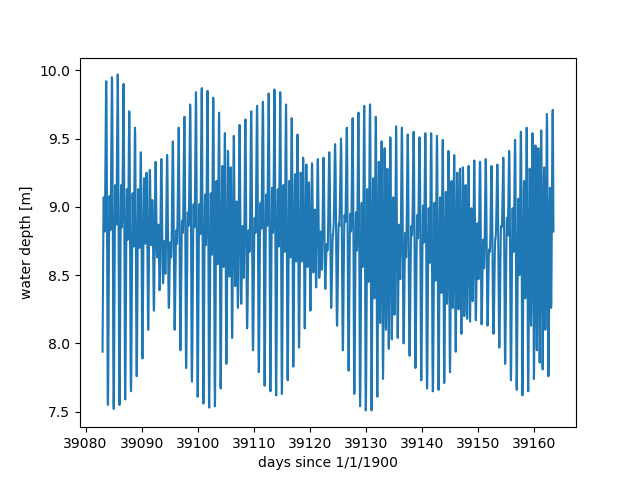

In [4]:
plt.figure()
plt.plot(time, waterdep)
plt.xlabel('days since 1/1/1900')
plt.ylabel('water depth [m]')

#### Exercise

Plot the time series of nitrate, salinity and temperature. Discuss the factors that determine nitrate conecentrations in Elkhorn Slough? 

<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/z7/lmyk7sz94177j166ck0x63h80000gr/T/ipykernel_43292/1442884851.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('nitrate [$\mu $M]')


Text(0, 0.5, 'nitrate [deg C]')

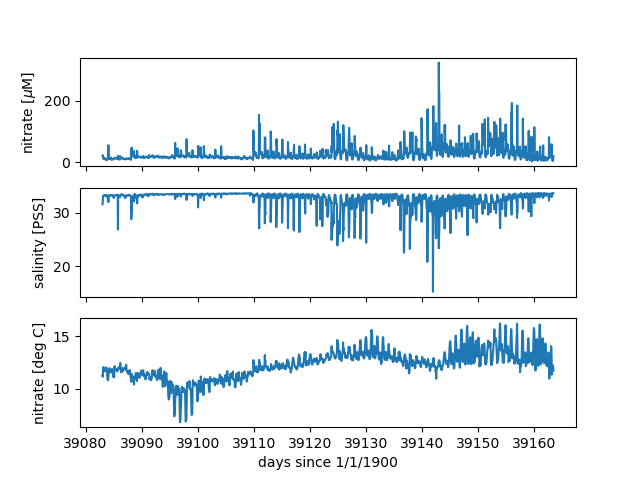

In [5]:
plt.figure()
plt.subplot(311)
plt.plot(time, nitrate)
plt.ylabel('nitrate [$\mu $M]')
plt.xticks(visible=False)

plt.subplot(312)
plt.plot(time, salinity)
plt.ylabel('salinity [PSS]')
plt.xticks(visible=False)

plt.subplot(313)
plt.plot(time, temp)
plt.xlabel('days since 1/1/1900')
plt.ylabel('nitrate [deg C]')

### Plotting the raw spectrum (or periodogram)

The course notes discuss how the periodogram can be computed from the discrete Fourier transform of the data. The signal processing library of SciPy includes a function that makes it much easier to compute the periodogram directly. It is called `periodogram`.

The `fs` argument is the sampling frequency (you can use whatever units you want as long as the value is consistent with the data. This function returns the frequency array (positive values only) and the corresponding PSD array. The values correspond exactly with those found above.

#### Exercises

* How many samples $N$ are in the time series?

In [6]:
N = len(waterdep)
print(N)

1932


* What is the sample interval $\Delta t$, in hours? In days?

In [7]:
deltat = time[1] - time[0]
print(deltat, ' days')

0.04166000000259373  days


In [8]:
print(deltat*24, 'hours')

0.9998400000622496 hours


* What is the fundamental frequency $f_f$ of the time series (in cycles per day)?

In [9]:
tmax = time[-1] - time[0]
f_f = 1/tmax
print(f_f, 'cpd') 

print(1/(N*deltat))

0.012428793886226372 cpd
0.012424348143376734


* What is the sampling frequency $f_s$ of the time series (in cycles per day)?

In [10]:
f_s  = 1/deltat
print(f_s, 'cpd')

24.003840613003852 cpd


* What is the Nyquist frequency $f_N$ of the time series (in cycles per day)?

In [11]:
f_N = 1/(2*deltat)
print(f_N, 'cpd')

12.001920306501926 cpd


### Periodogram plot - example

In [12]:
from scipy.signal import periodogram

In [13]:
fp, Sp = periodogram(waterdep, fs = f_s)

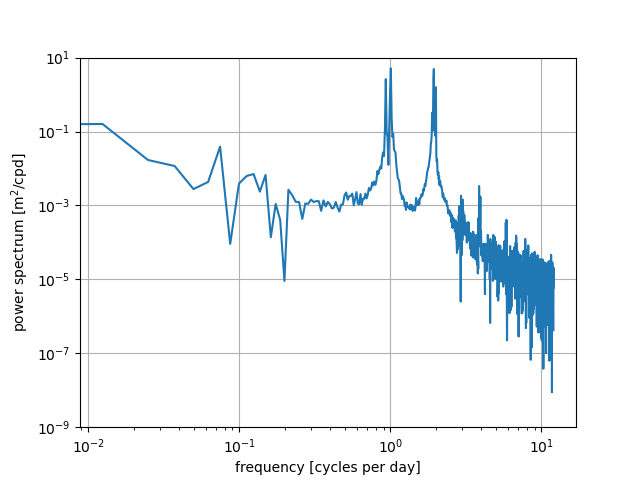

In [14]:
plt.figure()
plt.loglog(fp, Sp)
plt.ylim([1e-9, 1e1])
plt.xlabel('frequency [cycles per day]')
plt.ylabel('power spectrum [m$^2$/cpd]')
plt.grid()

In [15]:
fp[5]- fp[4]

np.float64(0.012424348143376736)

## Exercises

* Compute the periodogram for the LOBO nitrate data. Label the y-axis with the correct units. Compare the spectrum with that of the water level spectrum. What are some similarities and differences? 

In [16]:
fno3, Sno3 = periodogram(nitrate, fs = f_s)

<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/z7/lmyk7sz94177j166ck0x63h80000gr/T/ipykernel_43292/2725970855.py:5: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel('power spectrum [$\mu M{^2}$/cpd]')


Text(0, 0.5, 'power spectrum [$\\mu M{^2}$/cpd]')

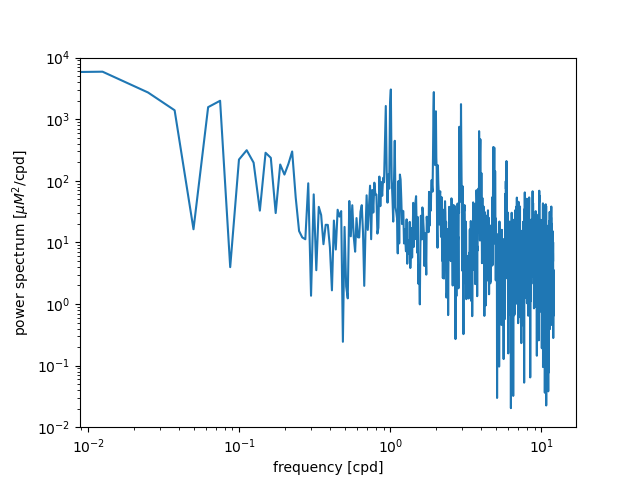

In [17]:
plt.figure()
plt.loglog(fno3, Sno3)
plt.ylim([1e-2, 1e4])
plt.xlabel('frequency [cpd]')
plt.ylabel('power spectrum [$\mu M{^2}$/cpd]')

### Better spectral estimates - example
* Sensible data windows
* Averaging
* Pre-whitening
* Confidence intervals

## Exploring 95% confidence intervals

In [21]:
from scipy.stats import chi2

### Filtering

In [36]:
from scipy.signal.windows import boxcar, hann
from physoce.tseries import pl64